Importing all the libraries


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Additional tools
from scipy import stats
import pickle

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

#For installing libraries use: !pip install library_name

Load and read file

In [17]:
import pandas as pd 

df = pd.read_csv(r'JSP_Dataset.csv')

print("First 5 rows of the dataset:\n")
print(df.head())

First 5 rows of the dataset:

            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes               0  165069  


Checking if the data is clean

In [18]:
# Checking the info of the dataset
df.info()

#Checking the descriptive statistics of the dataset
print(df.describe())

#Checking if there are any null values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.005408       9.997812        2.491928  145718.080524
std            6.060602       5.479288        1.706475   37407.9

Data Preprocessing


In [19]:
# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
# Remove target column if it appears (it's numeric, so usually not here)
if 'salary' in categorical_cols:
    categorical_cols.remove('salary')
print("Categorical columns to encode:", categorical_cols)

# For simplicity, we apply OneHotEncoder to all categorical features.
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after one‑hot encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns to encode: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
Shape after one‑hot encoding: (250000, 43)


,experience_years,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,109413,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,93764,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,148123,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,189123,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,165069,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


Exploratory Data Analysis (EDA):

1 Univariate Analysis – Distribution of Salary and Experience

2 Bivariate Analysis – Salary vs. Experience, Education, Skills

3 Correlation Heatmap (numeric features only)

4 Boxplots & Histograms for Key Categorical Features

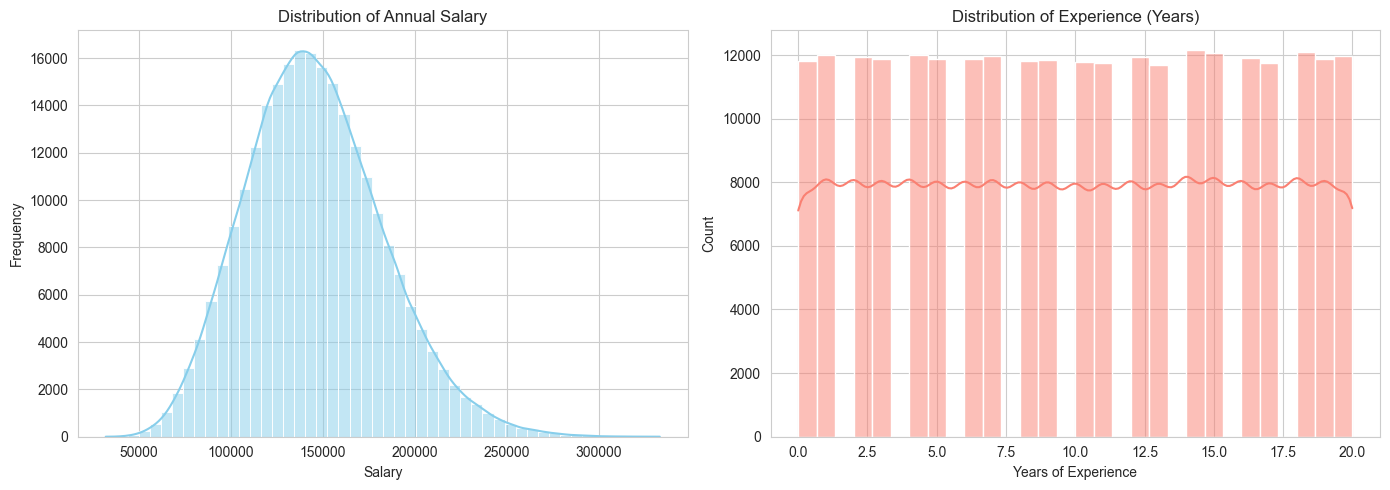

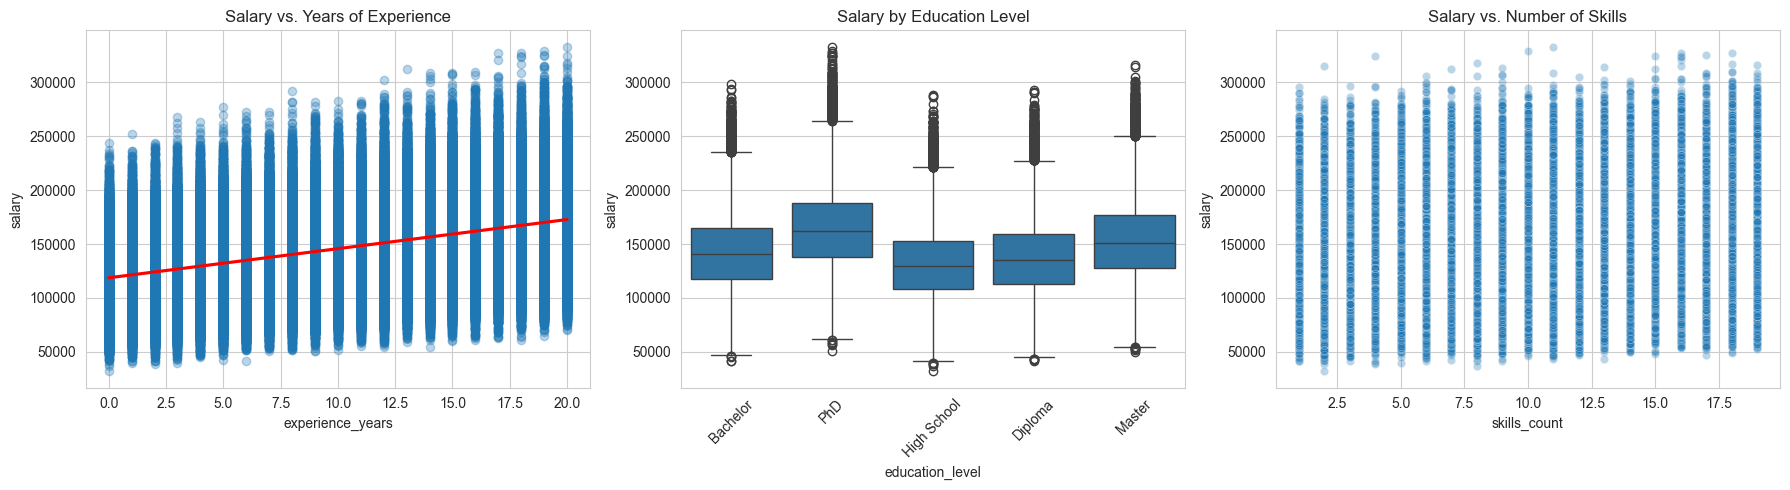

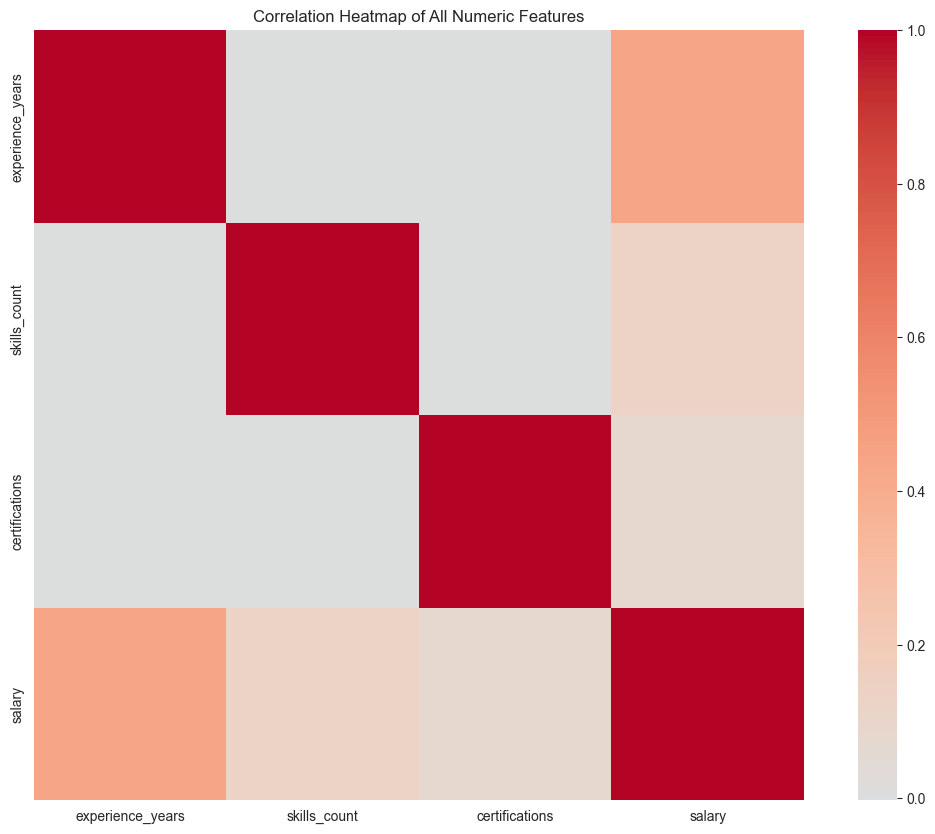

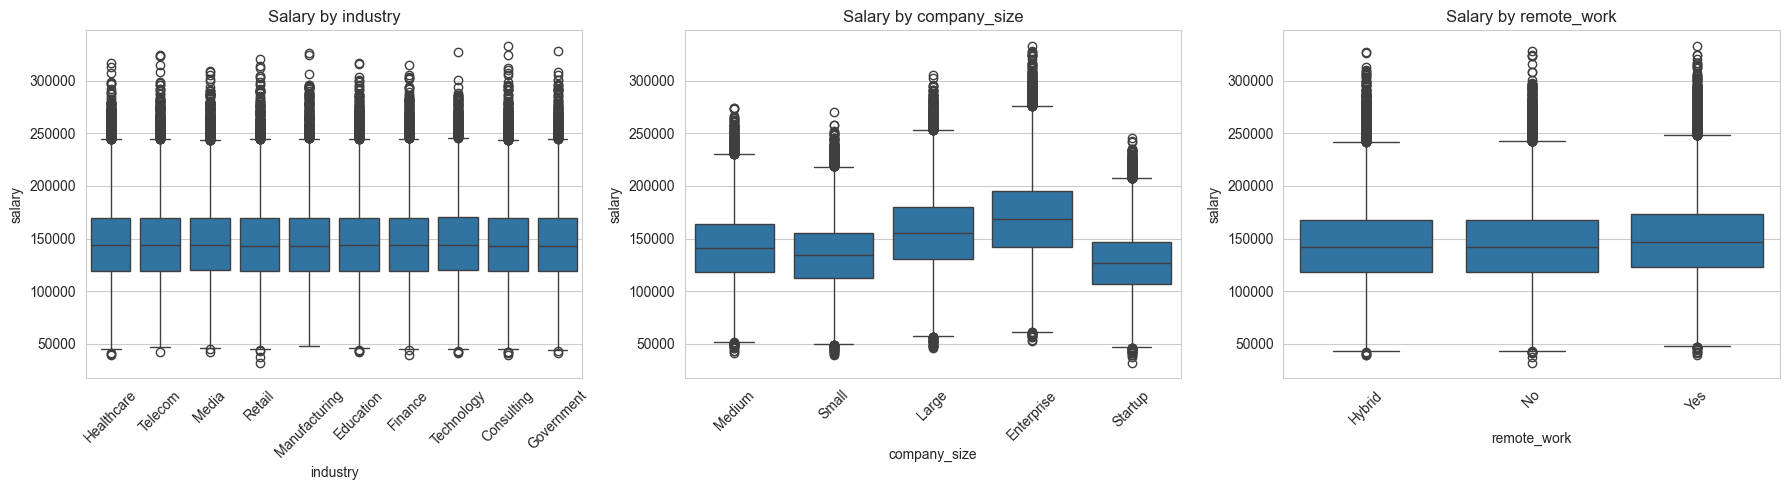

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Salary distribution – using df['salary']
sns.histplot(df['salary'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Annual Salary')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')

# Experience years distribution
sns.histplot(df['experience_years'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Experience (Years)')
axes[1].set_xlabel('Years of Experience')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Salary vs. Experience (scatter + regression line)
sns.regplot(x='experience_years', y='salary', data=df, ax=axes[0], 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Salary vs. Years of Experience')

# Salary vs. Education Level (boxplot)
sns.boxplot(x='education_level', y='salary', data=df, ax=axes[1])
axes[1].set_title('Salary by Education Level')
axes[1].tick_params(axis='x', rotation=45)

# Salary vs. Skills Count (scatter)
sns.scatterplot(x='skills_count', y='salary', data=df, ax=axes[2], alpha=0.3)
axes[2].set_title('Salary vs. Number of Skills')

plt.tight_layout()
plt.show()

numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
corr_matrix = df_encoded[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of All Numeric Features')
plt.show()

# Boxplots for salary across different categories
cat_features = ['industry', 'company_size', 'remote_work']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_features):
    sns.boxplot(x=col, y='salary', data=df, ax=axes[i])
    axes[i].set_title(f'Salary by {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Model Training

In [16]:
# Check if df_encoded exists; if not, you need to run the encoding cell first.
try:
    df_encoded
except NameError:
    raise NameError("df_encoded not defined. Please run the encoding cell (3.2) first.")

# Prepare features and target
X = df_encoded.drop('salary', axis=1)
y = df_encoded['salary']

# Train/test split (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size:     {X_test.shape[0]} rows")

# Scale features for Linear Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Use scaled data for Linear Regression, original for tree models
X_train_lr = X_train_scaled
X_test_lr = X_test_scaled
X_train_tree = X_train
X_test_tree = X_test

results = {}

for name, model in models.items():
    if name == 'Linear Regression':
        model.fit(X_train_lr, y_train)
        y_pred = model.predict(X_test_lr)
    else:
        model.fit(X_train_tree, y_train)
        y_pred = model.predict(X_test_tree)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2}
    print(f"{name}:\n  MAE = {mae:.2f}\n  MSE = {mse:.2f}\n  RMSE = {rmse:.2f}\n  R²  = {r2:.4f}\n")

Training set size: 200000 rows
Test set size:     50000 rows
Linear Regression:
  MAE = 5436.10
  MSE = 50773076.66
  RMSE = 7125.52
  R²  = 0.9635

Decision Tree:
  MAE = 7983.79
  MSE = 109330262.98
  RMSE = 10456.11
  R²  = 0.9213

Random Forest:
  MAE = 5693.02
  MSE = 54401789.15
  RMSE = 7375.76
  R²  = 0.9609

XGBoost:
  MAE = 5660.12
  MSE = 58557999.26
  RMSE = 7652.32
  R²  = 0.9579



Linear Regression is the best model for this dataset because it has the lowest error and highest R², showing the relationship is mostly linear

Evaluation & Comparison of Models

Model Performance Comparison:


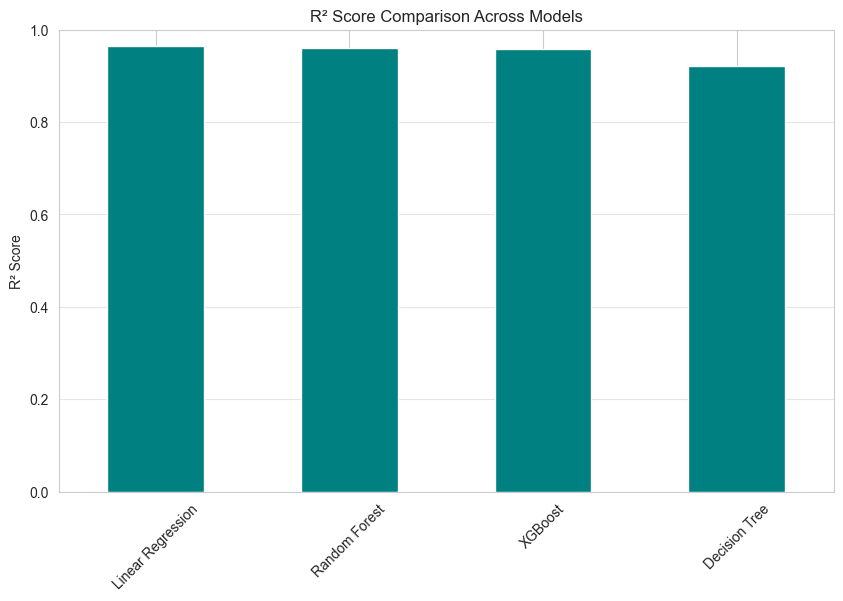

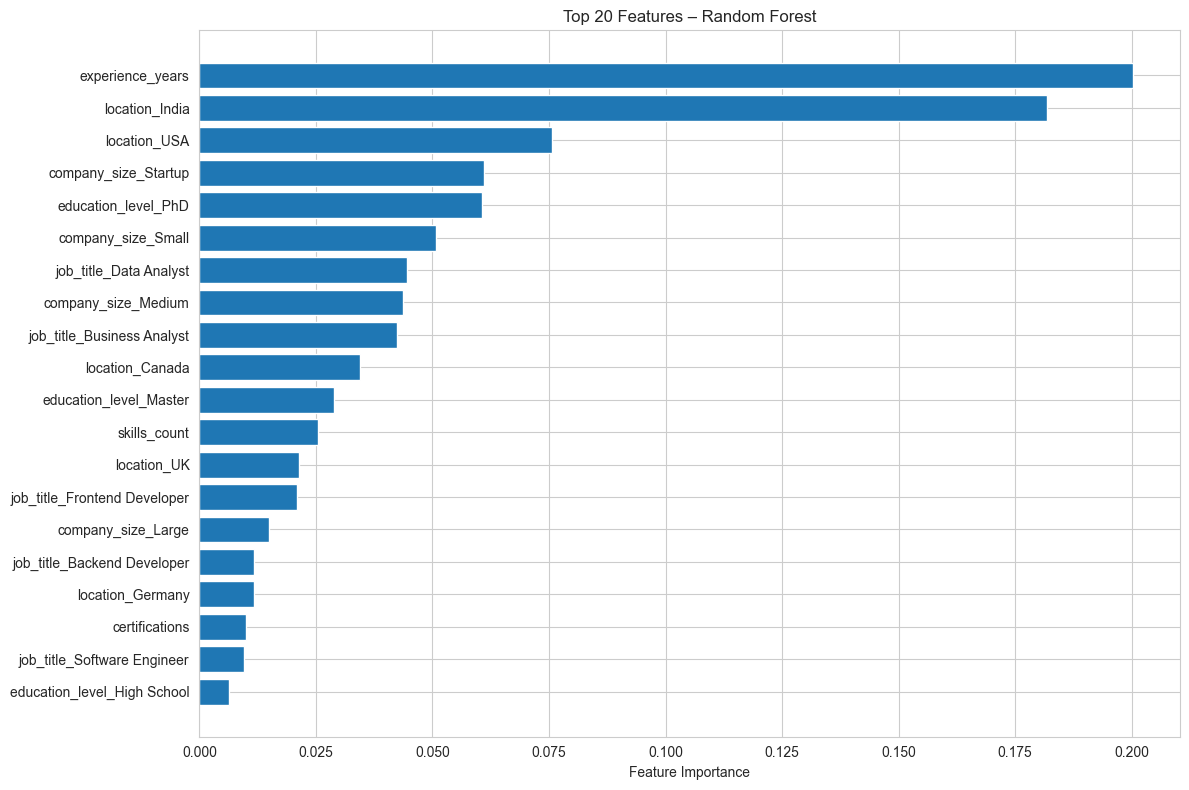

In [17]:
# Create a DataFrame for comparison
results_df = pd.DataFrame(results).T
results_df = results_df[['MAE', 'MSE', 'RMSE', 'R²']]

print("Model Performance Comparison:")
results_df

# Bar plot comparison of R² scores
plt.figure(figsize=(10, 6))
results_df['R²'].sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title('R² Score Comparison Across Models')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)
plt.show()

# Feature Importance (for tree‑based models)

# Feature importance from Random Forest
feature_importance = models['Random Forest'].feature_importances_
features = X_train.columns

# Sort and plot top 20 features
sorted_idx = np.argsort(feature_importance)[::-1][:20]
plt.figure(figsize=(12, 8))
plt.barh(range(20), feature_importance[sorted_idx][::-1], align='center')
plt.yticks(range(20), [features[i] for i in sorted_idx[::-1]])
plt.xlabel('Feature Importance')
plt.title('Top 20 Features – Random Forest')
plt.tight_layout()
plt.show()

ROC Curve

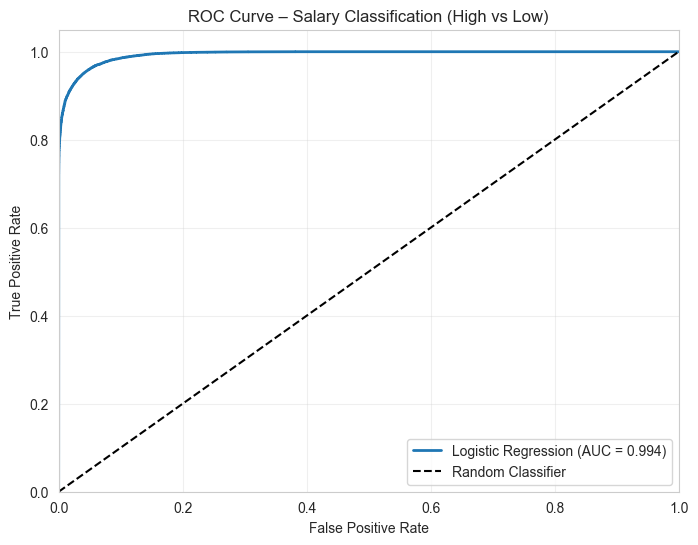

In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression

# Create binary target: 1 = high salary (> median), 0 = low salary (≤ median)
median_salary = y_train.median()
y_train_binary = (y_train > median_salary).astype(int)
y_test_binary = (y_test > median_salary).astype(int)

# Train a simple logistic regression on the scaled data
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train_binary)

# Predict probabilities
y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Salary Classification (High vs Low)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

AUC is not suitable for Linear Regression since it is a regression model. If an AUC score is obtained, it likely means the problem was converted into a classification task or there may be issues such as data leakage.

Best Model Selection & Saving with Pickle

In [19]:
# Find the best model based on R² (higher is better)
best_model_name = results_df['R²'].idxmax()
best_model = models[best_model_name]
print(f"Best model selected: {best_model_name}")
print(f"Performance:\n{results_df.loc[best_model_name]}")

# Save the best model and the scaler (if needed for inference)
with open('best_salary_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Also save the scaler if we need to preprocess future data for linear models
if best_model_name == 'Linear Regression':
    with open('scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

print("Model saved as 'best_salary_model.pkl'")

Best model selected: Linear Regression
Performance:
MAE     5.436097e+03
MSE     5.077308e+07
RMSE    7.125523e+03
R²      9.634690e-01
Name: Linear Regression, dtype: float64
Model saved as 'best_salary_model.pkl'


Visualizations: Actual vs. Predicted & Residuals

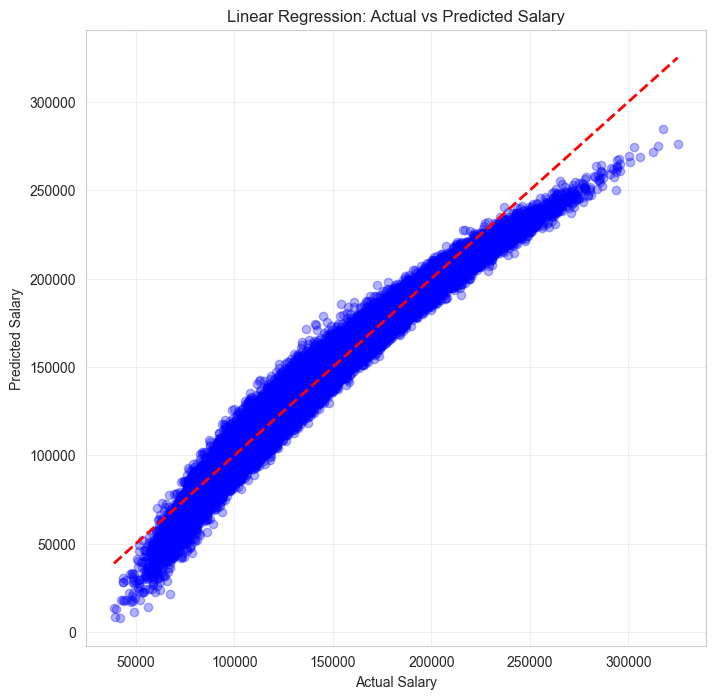

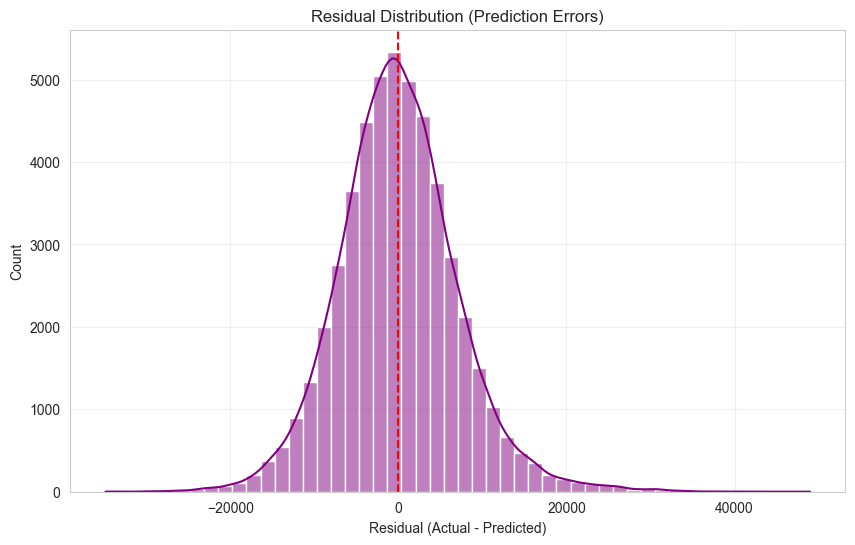

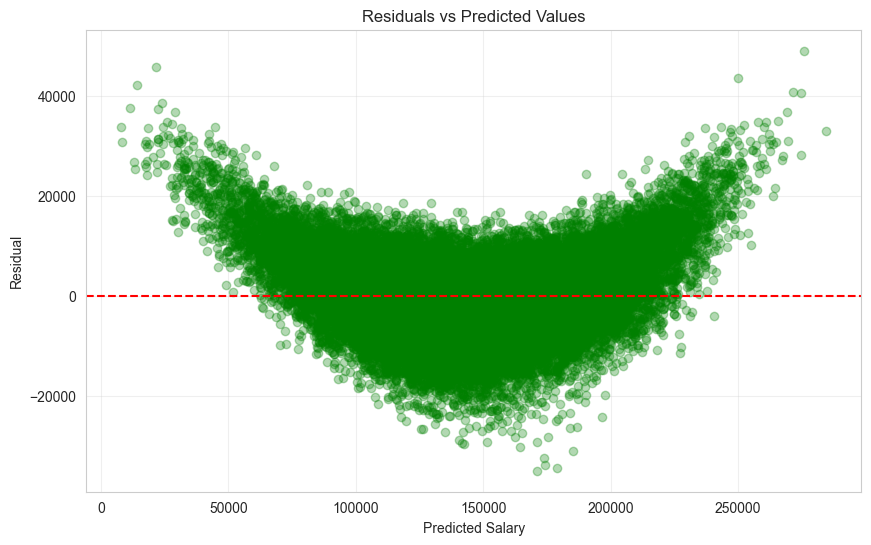

In [20]:
# Using the best model to generate predictions on the test set.


# Get predictions from the best model
if best_model_name == 'Linear Regression':
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test_tree)

# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title(f'{best_model_name}: Actual vs Predicted Salary')
plt.grid(alpha=0.3)
plt.show()

# Residual plot
residuals = y_test - y_pred_best
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True, color='purple')
plt.title('Residual Distribution (Prediction Errors)')
plt.xlabel('Residual (Actual - Predicted)')
plt.axvline(x=0, color='red', linestyle='--')
plt.grid(alpha=0.3)
plt.show()

# Residuals vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_best, residuals, alpha=0.3, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Salary')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Values')
plt.grid(alpha=0.3)
plt.show()

Final Output & Insights

In [21]:
print("="*60)
print("FINAL MODEL PERFORMANCE")
print("="*60)
print(f"Best model: {best_model_name}")
print(f"R² Score : {results_df.loc[best_model_name]['R²']:.4f}")
print(f"RMSE     : {results_df.loc[best_model_name]['RMSE']:.2f}")
print(f"MAE      : {results_df.loc[best_model_name]['MAE']:.2f}")

FINAL MODEL PERFORMANCE
Best model: Linear Regression
R² Score : 0.9635
RMSE     : 7125.52
MAE      : 5436.10
